# ML from DFT data

In [1]:
import pickle
import os
import glob
import numpy as np
import pdb
import pandas as pd
from importlib.machinery import SourceFileLoader
import re
import sys
from tqdm.notebook import tqdm_notebook
from seaborn import heatmap
import seaborn as sns
from BopFoxFeaturizer.HelperFunctions import get_useful_features
from BopFoxFeaturizer.HelperFunctions import cleanfeaturenames
from BopFoxFeaturizer.HelperFunctions import histoff_realfeatures
import matplotlib.pyplot as plt
plt.style.use('default')
plt.rc('figure', figsize=(15,10))
plt.rc('legend',fontsize=24)
plt.rc('axes',labelsize=28)
plt.rc('xtick',labelsize=24)
plt.rc('ytick',labelsize=24)
from BopFoxFeaturizer.FeatureConcatenate import stackdata
from BopFoxFeaturizer.brief_summary_parser import StructSummaryParser
from BopFoxFeaturizer.Featurizer import Featurizer
from BopFoxFeaturizer import HelperFunctions as HF
#stackdata = SourceFileLoader('stackdata','BopFoxFeaturizer/FeatureConcatenate.py').load_module().stackdata
# Original DFT Data
%run SourceDevelopementVersion.py
# which loads Featu
import glob

# Parameters 

In [2]:
CASE = 'INITIAL'  #, 'INITIAL', RELAXED
MODEL = 'CANONICAL' #, 'ORTHOGONAL', 'CANONICAL'
CUT_OFF = 'TABLECUTOFF' # 'TABLECUTOFF', 'HISTCUTOFF'
E_MODE ='WUBIND'
C_RITERION = 'test_score'  # test_score, train_score, err
SEARCH_MODE = 'score_only'

# Helpeer Functions 

In [3]:
from Tools import CaseNamer, Plotting

In [4]:
FileNames = CaseNamer(CASE, MODEL, CUTOFF=CUT_OFF, EMODE=E_MODE, CRITERION=C_RITERION, SEARCHMODE=SEARCH_MODE)

# Load Features

## Load briefsummary and its features

In [5]:
BS = StructSummaryParser().BriefSummary
Features = Featurizer(BS)

## Load the BOP for the selected case

In [6]:
BOPCOEF_FILE = f'CRCOW_{CASE}_NSC_{MODEL}_{CUT_OFF}_{E_MODE}.pkl'
BopfoxFeatures = pd.read_pickle(BOPCOEF_FILE)
BopfoxFeatures.drop(columns=['NSC_U_bond_atom_list'], inplace=True)
#BopfoxFeatures.drop(columns=['NSC_U_bind'], inplace=True)

## clean features: reduntandly convert all features to float and mean across sites

In [7]:
BopfoxFeatures.dropna(how='any',inplace=True)
M = BopfoxFeatures['NSC_moments'].map(lambda M: np.array(M).mean(axis=0))
S = BopfoxFeatures['NSC_SIGMA'].map(lambda M: np.array(M).mean(axis=0))
Binf=BopfoxFeatures['NSC_Binf'].map(lambda s: [float(si) for si in s]).map(np.mean)
Ainf=BopfoxFeatures['NSC_Ainf'].map(lambda s: [float(si) for si in s]).map(np.mean)
AN = BopfoxFeatures['NSC_an'].map(lambda M: np.array(M).mean(axis=0))
BN = BopfoxFeatures['NSC_bn'].map(lambda M: np.array(M).mean(axis=0))
Mag = Features.MagFeature[BopfoxFeatures.index]
BOP_atom_average = pd.concat([BopfoxFeatures['NSC_U_bind'],M, S, AN, BN, Ainf, Binf, Mag], axis=1)
# Feature Transformation to concatenation
BOP, names = stackdata(BOP_atom_average, BOP_atom_average.columns.values)
BOP = pd.DataFrame(data=BOP, columns=names, index = BOP_atom_average.index)

## define the column names by type of feature

In [8]:
allcolumns = BOP.columns

In [9]:
columns_Mag =BOP.columns[BOP.columns.str.contains('MagConfig')]
columns_U =BOP.columns[BOP.columns.str.contains('U_bind')]
columns_bn = BOP.columns[BOP.columns.str.contains('bn')]
columns_sigma =BOP.columns[BOP.columns.str.contains('SIGMA')] 
columns_moments = BOP.columns[BOP.columns.str.contains('moment')]
columns_an = BOP.columns[BOP.columns.str.contains('an')]

In [10]:
feature_titles = pd.Series(
    HF.cleanfeaturenames([ s.replace('NSC_','').replace('MagConfig_0','MagConfig').replace('bind_0','bind') for s in allcolumns ]), index=allcolumns
)

In [11]:
columns_U

Index(['NSC_U_bind_0'], dtype='object')

In [12]:
real_feature = HF.get_useful_features(BOP, allcolumns)

In [13]:
def colsgroup(kind):
    return [ f for f in real_feature if kind in f] 

In [14]:
useful = {f: colsgroup(f) for f in ['an','bn','moment','SIGMA', 'U_bind','MagConfig']}

# Targets

$ \Delta E_F  = \dfrac{1}{N_{atoms}} \left( E_{Total} - \sum _{i} N_i E_i \right) $

In [15]:
groundstates=Features.get_ground_states_energies()
BS['EF'] = Features.get_formation_energy(ground_states_dic=groundstates)
BS = BS.dropna()
DATA = BOP.copy()
DATA[['B0','V0','EF','E0']]=BS[['B0','V0','EF','E0']]

## Distribution of targets

### $E_{F}$

In [16]:
Out_In_First = DATA[~((DATA['EF']>-1) & (DATA['EF']<2))]

In [17]:
DATA = DATA[(DATA['EF'] > -1) & (DATA['EF']< 2)]

### $E_0$

In [18]:
DATA = DATA[(DATA['E0']>-100) & (DATA['E0']<10)]

In [19]:
DATA.shape

(1684, 90)

## B0

In [20]:
DATA = DATA[(DATA['B0'])>0 & (DATA['B0']<500)]

## Drop Nans !

In [21]:
DATA.dropna(how='any', axis=0,inplace=True)

# Classification and weighting

Text(0, 0.5, '')

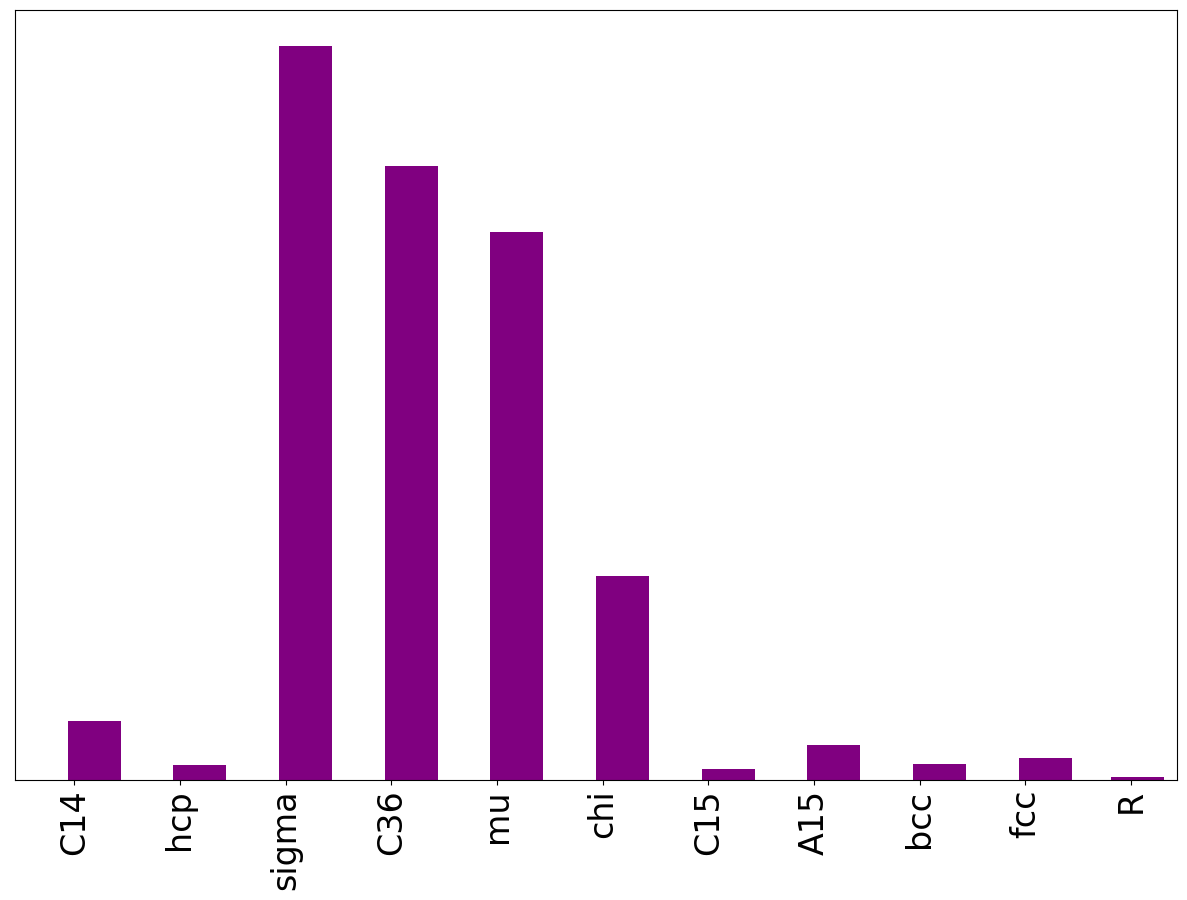

In [22]:
from BopFoxFeaturizer.struct_db import struct_db
#struct_db = SourceFileLoader('struct_db','BopFoxFeaturizer/struct_db.py').load_module().struct_db
strucdic = struct_db().strucstrings

Target_Class = pd.Series(
    DATA.index.str.split('.').map(lambda l: l[1]).map(lambda s: s.split('-')[0]),
    index=DATA.index
)
Target_Class[Target_Class.map(lambda s: s in strucdic['list.hcp'])]='hcp'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.fcc'])]='fcc'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.bcc'])]='bcc'
Target_Class[Features.Struc == 'hcp'] = 'hcp'
Target_Class[Features.Struc == 'bcc'] = 'bcc'
Target_Class[Features.Struc == 'fcc'] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-fcc')] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-L12')] = 'fcc'
Target_Class[Features.Struc.str.contains('sigma_')] = 'sigma'

Target_Class[    
    Target_Class.str.contains('Al42W') |\
    Target_Class.str.contains('Al9Co2') |\
    Target_Class.str.contains('Al5W') |\
    Target_Class.str.contains('Al12W') |\
    Target_Class.str.contains('Al4W') |\
    Target_Class.str.contains('Al5Co2')
] = 'others'

plt.hist(Target_Class, bins=80, density = True, width=0.5, align='left', color = 'purple')
plt.xticks(rotation=90); yticks = plt.yticks([])
plt.ylabel('')

## Class Weights

In [23]:
Classes = pd.DataFrame(Target_Class.values, columns=['Class'], index=DATA.index)
Target_Class_Count = Target_Class.value_counts()
Classes['Weights'] = 1/(Target_Class_Count[Target_Class]/Target_Class_Count.sum()).values #Target_Class_Count.sum()

In [24]:
data_w_classes =pd.concat([DATA,Classes['Class'].loc[DATA.index]], axis=1) 

# Finally some Machine Learning

[![scikit-logo](https://scikit-learn.org/stable/_static/scikit-learn-logo-small.png#background-color:"#FFFFFF")](https://scikit-learn.org/stable/) is a standard tool for machine learning in python. The documentation in their webpage is often a good refference for tutorials, methods and Theory of Machine Learning. 

In [25]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.preprocessing import MinMaxScaler

## Helper Functions for ML

In [26]:
def plot_the_errors(THISERRORS,thecase):
    alltheclases = np.unique(Classes['Class'])
    thebadclasses = ['hcp', 'bcc', 'fcc','others','delta','R','C15']
    thegoodclases = [c for c in alltheclases if c not in thebadclasses ]
    fig, ax = plt.subplots(len(thegoodclases),1, sharex=True, figsize =(10,2*len(thegoodclases)))
    for i, classes in enumerate(thegoodclases) :
        thiserrors = np.abs(THISERRORS[Classes['Class']==classes])
        e = ax[i].hist (thiserrors, density=False, bins=100, label=classes)
        ax[i].annotate(classes, (0.8,0.5),xycoords = 'axes fraction', fontsize=20)
#    ax[-1].set_xlim([-0.01,1.0])
    ax[-1].set_ylabel('Density Counts',y=4), plt.xlabel('$|  E_F^{predicted} -  E_F^{True} | $')
    fig.tight_layout()
    fig.savefig(FileNames.get_plot_filename('Errors_by_class', thecase))
#    fig.savefig('graphs/Errors_by_class_{}_{}_{}_{}.pdf'.format(case, CASE, MODEL, CUTOFF))
    

def plot_the_prediction_line(theprediction, thepredictionovertest, thecase):
    fig, ax = plt.subplots()
    ax.plot(theprediction, DATA['EF'],'o', label='full dataset')
    ax.plot(thepredictionovertest, Y_test['EF'],'o', label='test set')
    ax.plot(DATA['EF'], DATA['EF'],'-k')
    ax.legend()
    ax.set_xlabel('True $\Delta E_F$')
    ax.set_ylabel('predicted $\Delta E_F$')
    fig.savefig(FileNames.get_plot_filename('Predictionline',thecase))
#    fig.savefig('graphs/predictionline_{}_{}.pdf'.format(themodel,CASE, MODEL, CUTOFF))

def train_test_errors(themodel, thetarget):
    Y_predict_train = themodel.predict(X_train)
    Y_predict_test = themodel.predict(X_test)
    return {'train': mean_squared_error(Y_train[thetarget], Y_predict_train ,squared=False), 'test':  mean_squared_error(Y_test[thetarget], Y_predict_test,squared=False )}

def make_simple_pipe(model):
    simple_model = Pipeline([('regressor', model())])
    return simple_model

I need Lists of errors to compare methods

In [27]:
mses = {}

I also need to remove targets from feature names

## simple regressor - random forest

In [28]:
simple_model = {'E0': make_simple_pipe(RandomForestRegressor), 'EF': make_simple_pipe(RandomForestRegressor)}

X_train, X_test, w_train, w_test,  Y_train, Y_test = train_test_split(DATA[real_feature],Classes['Weights'], DATA[['EF','E0']],test_size=0.2, shuffle=True)

simple_model['EF'].fit(X_train, Y_train['EF']) #, sample_weight=w_train)

simple_model['E0'].fit(X_train, Y_train['E0']) #, sample_weight=w_train)

Pipeline(steps=[('regressor', RandomForestRegressor())])

In [29]:
mses['random forest regressor'] = {
    'E0': train_test_errors(simple_model['E0'],'E0'), 
    'EF': train_test_errors(simple_model['EF'],'EF')
}

In [30]:
mses

{'random forest regressor': {'E0': {'train': 1.1027114285331905,
   'test': 1.2476589931226711},
  'EF': {'train': 0.15376155911974868, 'test': 0.17883209221447174}}}

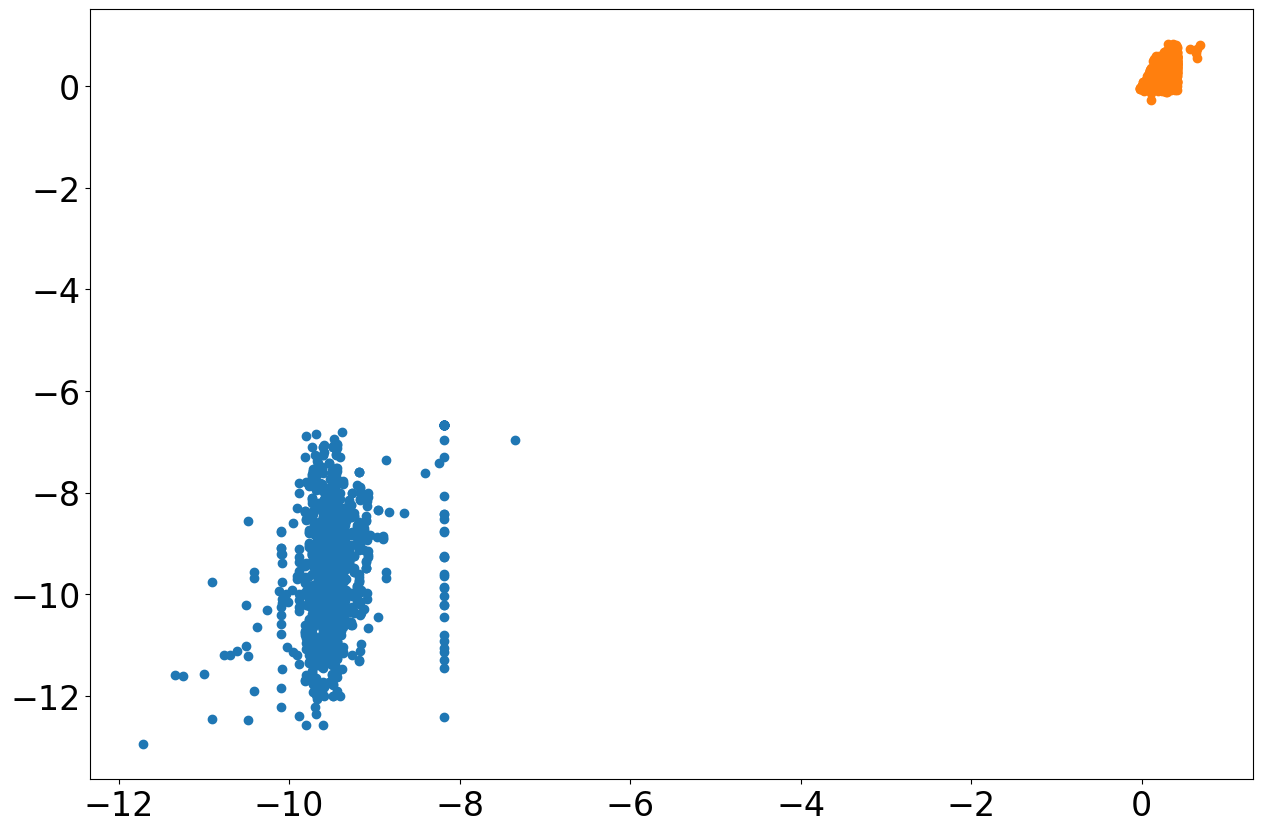

In [31]:
plt.plot(simple_model['E0'].predict(X_train),Y_train['E0'],'o')
plt.plot(simple_model['EF'].predict(X_train),Y_train['EF'],'o')

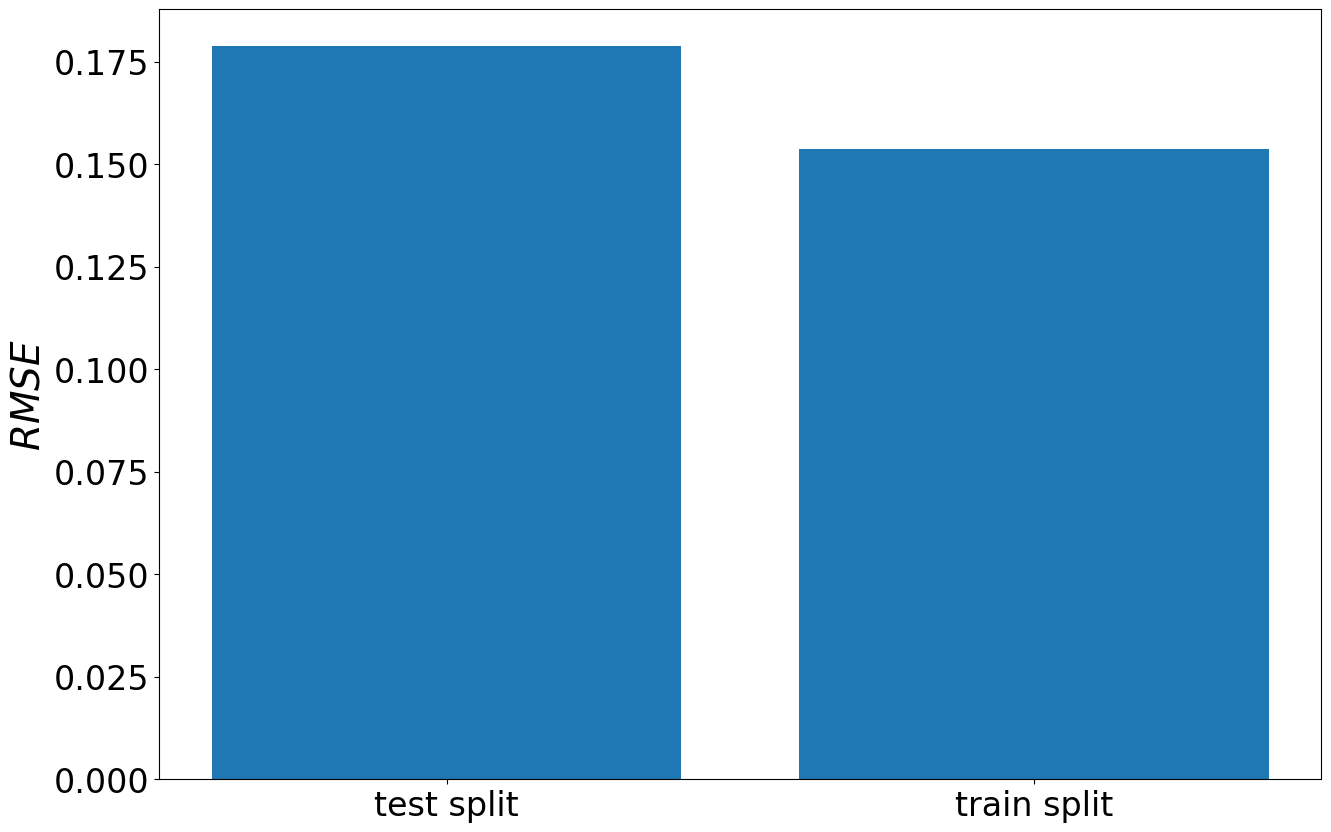

In [32]:
plt.bar(['test split','train split'],[mses['random forest regressor']['EF']['test'], mses['random forest regressor']['EF']['train']])
label = plt.ylabel('$RMSE$')

In [33]:
YPREDICT = simple_model['EF'].predict(DATA[real_feature])
Y_predict_test = simple_model['EF'].predict(X_test)
ERRORS = (YPREDICT - DATA['EF']).map(np.abs)

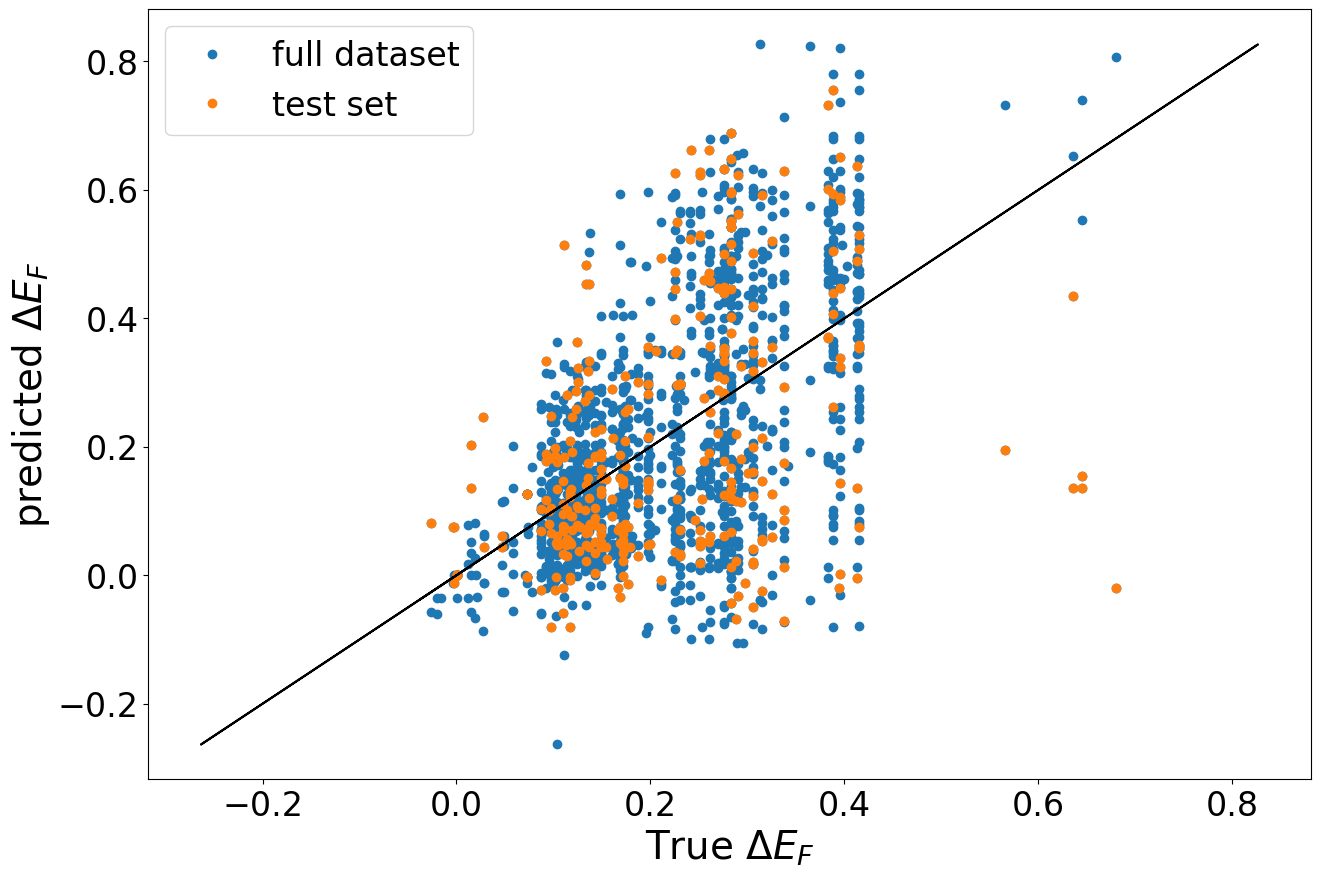

In [34]:
plot_the_prediction_line(YPREDICT, Y_predict_test, 'RandomForestRegressor')

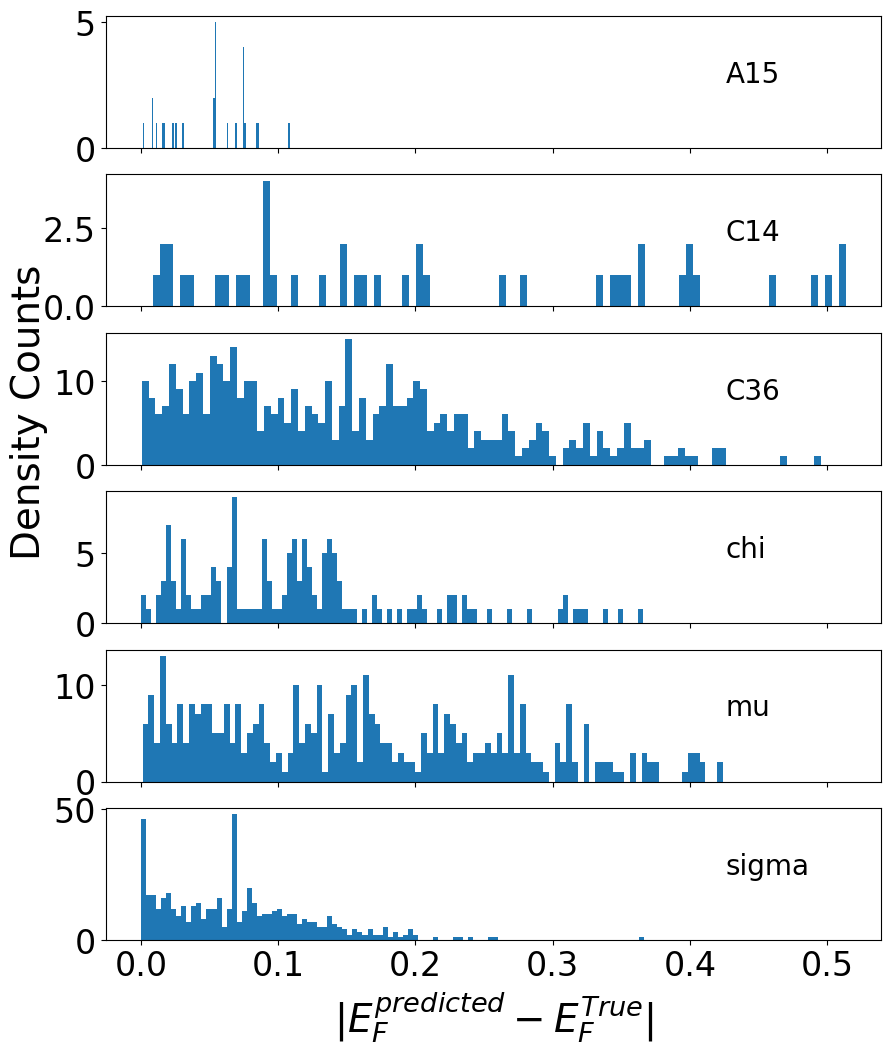

In [35]:
plot_the_errors(ERRORS,'RandomForestRegressor')

There is a big variety of regression methods available in scikit-learn package.
[See the documentation](https://scikit-learn.org/stable/supervised_learning.html#supervised-learninghttps://scikit-learn.org/stable/supervised_learning.html#supervised-learning)

# Feature Selection

In [36]:
Bestfeats = {}
Bestscores = {}
FC={}
criterion = 'test_score'

## Random Forest

useful_feature = useful['an']+useful['bn']+useful['moment']+useful['SIGMA']+\
                ['MagConfig_0','NSC_Ainf_0', 'NSC_Binf_0']

In [37]:
# This is the standard way to import modules
del FeatureConcatenate
# from BopFoxFeaturizer.FeatureConcatenate import FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate

#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
FC['RandomForest'] = FeatureConcatenate(
    #pd.concat([X_train, Y_train['EF']], axis=1), #DATA, 
    DATA[real_feature+['EF']],
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=real_feature,
    data_target='EF',
    criterion = C_RITERION,
    sort_criteria='score_only'
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest'], Bestscores['RandomForest'] = FC['RandomForest'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    maxnumfeatures=10,
    pass_force_refit=True,
    report_prefix='RandomForest_'+CASE
)

procesing '[]' with 'MagConfig_0' ... ::   0%|                                                    | 0/1 [00:00<?, ?it/s]

Refitting ..


procesing '[]' with 'MagConfig_0' ... :: 100%|############################################| 1/1 [00:00<00:00,  1.39it/s]
procesing '['MagConfig_0']' with 'NSC_bn_10' ... ::   0%|                                        | 0/60 [00:00<?, ?it/s]

fitting has finished,  test_score  =  0.18836471653590886
Refitting ..


procesing '['MagConfig_0']' with 'NSC_bn_5' ... :: 100%|################################| 60/60 [00:52<00:00,  1.15it/s]


...

fitting has finished,  test_score  =  0.17693801233406256
Refitting ..


procesing '['MagConfig_0', 'NSC_an_3', 'NSC_bn_1', 'NSC_SIGMA_13', 'NSC_SIGMA_17']' with 'NSC_SIGMA_3' ... :: 100%|#| 2/
procesing '['MagConfig_0', 'NSC_an_3', 'NSC_bn_1', 'NSC_SIGMA_13', 'NSC_SIGMA_17', 'NSC_SIGMA_7']' with 'NSC_SIGMA_3' ..

fitting has finished,  test_score  =  0.1777872569493834
Refitting ..


procesing '['MagConfig_0', 'NSC_an_3', 'NSC_bn_1', 'NSC_SIGMA_13', 'NSC_SIGMA_17', 'NSC_SIGMA_7']' with 'NSC_SIGMA_3' ..

fitting has finished,  test_score  =  0.1776114150940273


In [38]:
FileNames = SourceFileLoader('FileNames','Tools.py').load_module().CaseNamer(CASE, MODEL, CUTOFF=CUT_OFF, EMODE=E_MODE, CRITERION=C_RITERION, SEARCHMODE=SEARCH_MODE)

In [39]:
thisdata = pd.DataFrame(np.array([[x, y] for x, y in zip(Bestfeats['RandomForest'], Bestscores['RandomForest'])]))

In [40]:
thisdata.to_csv(
    FileNames.get_table_filename('BopFeatures_Ubind',FC['RandomForest'].sort_criteria),
    header=False, index=False
)

In [41]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_an'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'an' in f or 'bn' in f],
    data_target='EF',
    criterion = criterion
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_an'], Bestscores['RandomForest_an'] = \
    FC['RandomForest_an'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_an_'+CASE,
)

procesing '[]' with 'MagConfig_0' ... ::   0%|                                                    | 0/1 [00:00<?, ?it/s]

Refitting ..


procesing '[]' with 'MagConfig_0' ... :: 100%|############################################| 1/1 [00:00<00:00,  1.45it/s]
procesing '['MagConfig_0']' with 'NSC_an_1' ... ::   0%|                                         | 0/19 [00:00<?, ?it/s]

fitting has finished,  test_score  =  0.19879799006434504
Refitting ..


procesing '['MagConfig_0']' with 'NSC_bn_8' ... :: 100%|################################| 19/19 [00:16<00:00,  1.14it/s]


fitting has finished,  test_score  =  0.17832199225865702


procesing '['MagConfig_0', 'NSC_bn_9']' with 'NSC_an_1' ... ::   0%|                              | 0/9 [00:00<?, ?it/s]

Refitting ..


procesing '['MagConfig_0', 'NSC_bn_9']' with 'NSC_an_4' ... :: 100%|######################| 9/9 [00:08<00:00,  1.06it/s]

fitting has finished,  test_score  =  0.17619619147584004


In [42]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_bn'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'bn' in f],
    data_target='EF',
    criterion = criterion
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_bn'], Bestscores['RandomForest_bn'] = FC['RandomForest_bn'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_bn_'+CASE,
)

procesing '[]' with 'MagConfig_0' ... ::   0%|                                                    | 0/1 [00:00<?, ?it/s]

Refitting ..


procesing '[]' with 'MagConfig_0' ... :: 100%|############################################| 1/1 [00:00<00:00,  1.44it/s]
procesing '['MagConfig_0']' with 'NSC_bn_6' ... ::   0%|                                         | 0/10 [00:00<?, ?it/s]

fitting has finished,  test_score  =  0.19857899682922087
Refitting ..


procesing '['MagConfig_0']' with 'NSC_bn_8' ... :: 100%|################################| 10/10 [00:08<00:00,  1.13it/s]

fitting has finished,  test_score  =  0.17733153658732115


In [43]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_sigma'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'SIGMA' in f],
    data_target='EF',
    criterion = criterion, sort_criteria='index_too'
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_sigma'], Bestscores['RandomForest_sigma'] = FC['RandomForest_sigma'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_sigma_'+CASE,
)

procesing '[]' with 'MagConfig_0' ... ::   0%|                                                    | 0/1 [00:00<?, ?it/s]

Refitting ..


procesing '[]' with 'MagConfig_0' ... :: 100%|############################################| 1/1 [00:00<00:00,  1.43it/s]
procesing '['MagConfig_0']' with 'NSC_SIGMA_16' ... ::   0%|                                     | 0/19 [00:00<?, ?it/s]

fitting has finished,  test_score  =  0.19859804158126942
Refitting ..


procesing '['MagConfig_0']' with 'NSC_SIGMA_7' ... :: 100%|#############################| 19/19 [00:14<00:00,  1.32it/s]
procesing '['MagConfig_0', 'NSC_SIGMA_1']' with 'NSC_SIGMA_17' ... ::   0%|                      | 0/11 [00:00<?, ?it/s]

...

fitting has finished,  test_score  =  0.18268676888274457
Refitting ..


procesing '['MagConfig_0', 'NSC_SIGMA_1', 'NSC_SIGMA_2', 'NSC_SIGMA_5', 'NSC_SIGMA_7']' with 'NSC_SIGMA_14' ... :: 100%|
procesing '['MagConfig_0', 'NSC_SIGMA_1', 'NSC_SIGMA_2', 'NSC_SIGMA_5', 'NSC_SIGMA_7', 'NSC_SIGMA_14']' with 'NSC_SIGMA_

fitting has finished,  test_score  =  0.1825248141060425
Refitting ..


procesing '['MagConfig_0', 'NSC_SIGMA_1', 'NSC_SIGMA_2', 'NSC_SIGMA_5', 'NSC_SIGMA_7', 'NSC_SIGMA_14']' with 'NSC_SIGMA_

fitting has finished,  test_score  =  0.18296473482680098


In [44]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_moments'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'moments' in f],
    data_target='EF',
    criterion = criterion
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_moments'], Bestscores['RandomForest_moments'] = FC['RandomForest_moments'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_moments_'+CASE,
)

procesing '[]' with 'MagConfig_0' ... ::   0%|                                                    | 0/1 [00:00<?, ?it/s]

Refitting ..


procesing '[]' with 'MagConfig_0' ... :: 100%|############################################| 1/1 [00:00<00:00,  1.44it/s]
procesing '['MagConfig_0']' with 'NSC_moments_2' ... ::   0%|                                    | 0/19 [00:00<?, ?it/s]

fitting has finished,  test_score  =  0.19869205811599128
Refitting ..


procesing '['MagConfig_0']' with 'NSC_moments_18' ... :: 100%|##########################| 19/19 [00:16<00:00,  1.14it/s]


fitting has finished,  test_score  =  0.1786928417120196


procesing '['MagConfig_0', 'NSC_moments_17']' with 'NSC_moments_2' ... ::   0%|                   | 0/9 [00:00<?, ?it/s]

Refitting ..


procesing '['MagConfig_0', 'NSC_moments_17']' with 'NSC_moments_18' ... :: 100%|##########| 9/9 [00:08<00:00,  1.06it/s]

fitting has finished,  test_score  =  0.1775972146115099


In [45]:
def plot_learning_curve(thescores, thefeatures, ax=None, modelname='RandomForest',dothelabels = True):
    if ax is None:
        fig, ax = plt.subplots()
    ax.plot(np.arange(1,len(thescores)+1),thescores) 
    ax.set_ylabel ("RMSE "+C_RITERION)
    ax.set_xlabel ("number of features")
    if dothelabels:
        for i, feat in enumerate(thefeatures):
            t = plt.annotate(
                feature_titles[feat],
                ((i+1), thescores[i]),
                ((i+1), thescores[i]),
                fontsize=22,
            )
            t.set_bbox(dict(facecolor='white', alpha=0.5))

    plt.savefig(FileNames.get_plot_filename('LearningCurve', modelname))
    return ax

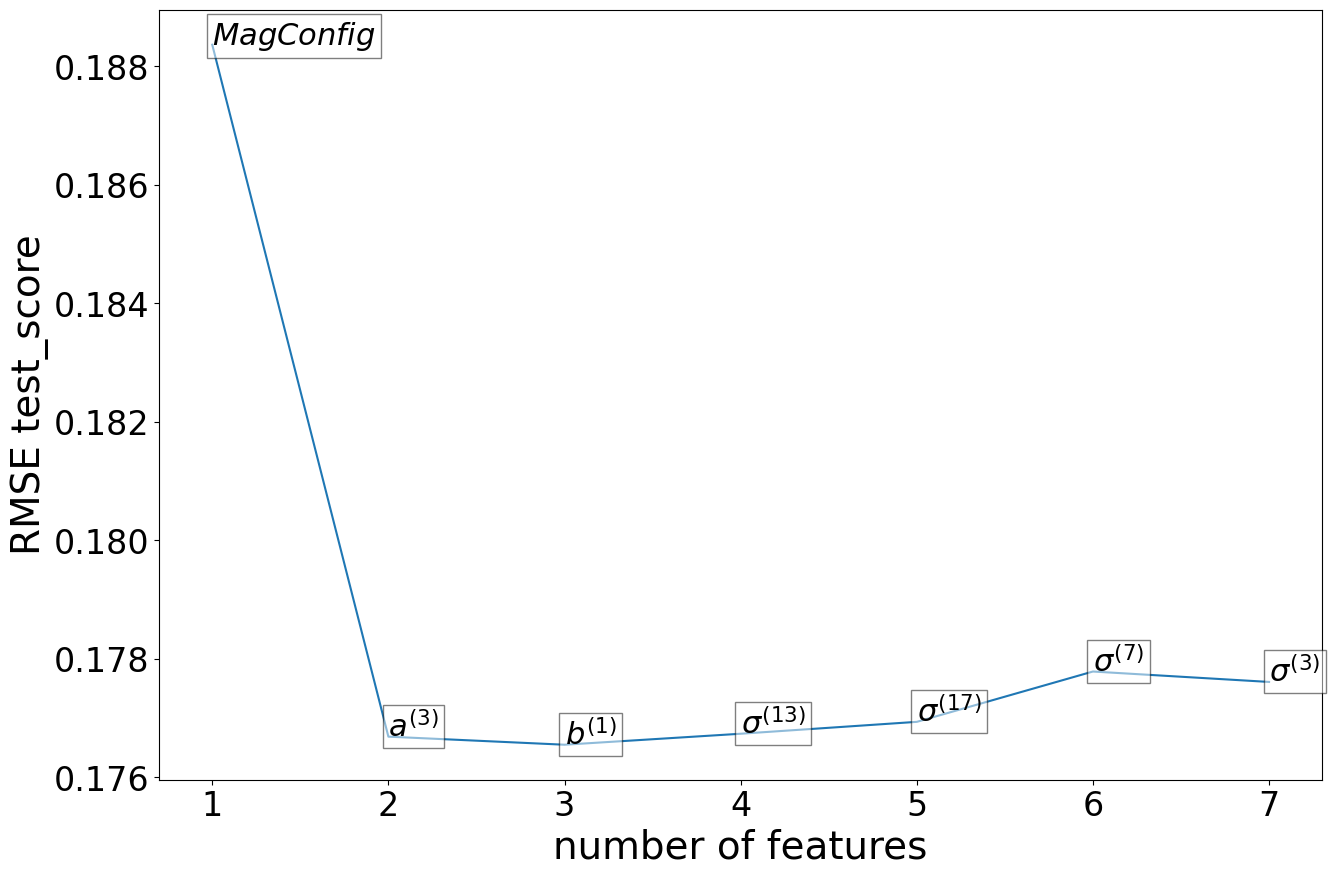

In [46]:
ax1 = plot_learning_curve(Bestscores['RandomForest'],Bestfeats['RandomForest'])
#ax2 = plot_learning_curve(Bestscores['RandomForest_an'],Bestfeats['RandomForest_an'], ax=ax1)
#ax2 = plot_learning_curve(Bestscores['RandomForest_moments'],Bestfeats['RandomForest_moments'], ax=ax1)

In [47]:
feature_titles = feature_titles[feature_titles  != '']

# The Errors

In [48]:
YPREDICT = FC['RandomForest'].report['best_estimator'].iloc[-1].predict(DATA[Bestfeats['RandomForest']])
EPREDICT = np.abs(YPREDICT - DATA['EF'])

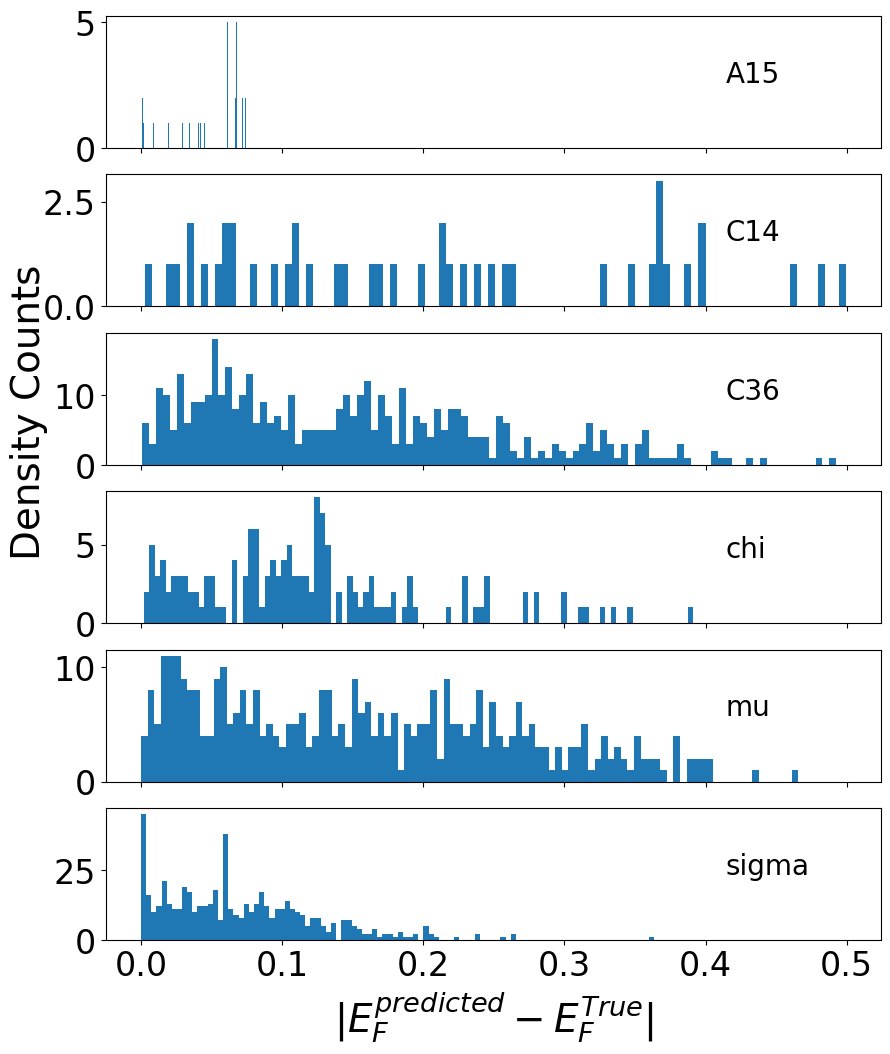

In [49]:
plot_the_errors(EPREDICT,'FeatureSelectionRandomForest')

# incremental simple model

In [50]:
def incremental_learn (columnsgroup):
    incremental_score = [] 
    progress = tqdm_notebook(range(1,len(columnsgroup)))
    for max_index in progress:
        incremental_model = RandomForestRegressor()
        feature_group = np.hstack((['MagConfig_0'], np.ravel(columnsgroup[:max_index])))#  + list(columns_bn[:max_index])
        this_feature_list = feature_group
        THHEX =DATA[feature_group].loc[X_train.index]
        incremental_model.fit(THHEX , Y_train['EF'])
        Ytrain_predict = incremental_model.predict(THHEX)
        Ytest_predict = incremental_model.predict(DATA[feature_group].loc[X_test.index])
        incremental_score.append(mean_squared_error(Y_test['EF'], Ytest_predict, squared=False))
    return incremental_score

In [51]:
cols_an_bn = [[an, bn] for an, bn in zip(columns_an, columns_bn) ]

In [52]:
incremental_score_moments = incremental_learn(columns_moments)
np.savetxt(FileNames.get_table_filename('incremental_score','moments'),incremental_score_moments)

  0%|          | 0/19 [00:00<?, ?it/s]

In [53]:
incremental_score_an = incremental_learn(cols_an_bn)
np.savetxt(FileNames.get_table_filename('incremental_score','an'),incremental_score_an)

  0%|          | 0/20 [00:00<?, ?it/s]

In [54]:
incremental_score_sigmas = incremental_learn(columns_sigma)
np.savetxt(FileNames.get_table_filename('incremental_score','sigmas'),incremental_score_sigmas)

  0%|          | 0/19 [00:00<?, ?it/s]

In [55]:
from matplotlib.ticker import FormatStrFormatter

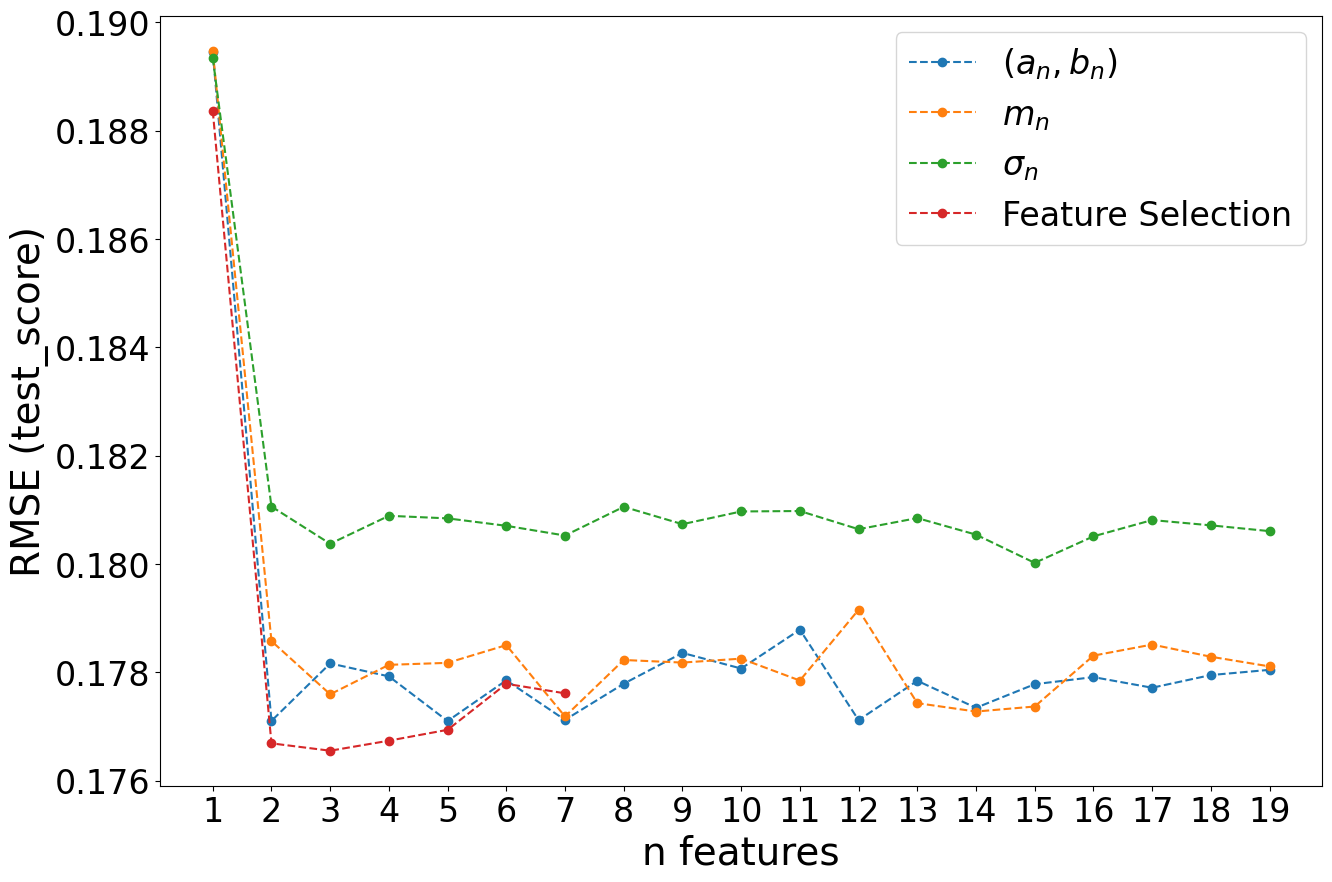

In [56]:
thex = np.linspace(1,len(incremental_score_moments), len(incremental_score_moments))
fig, ax = plt.subplots()
ax.plot(thex, incremental_score_an[:-1],'--o', label = ('$(a_n,b_n)$'))
ax.plot(thex , incremental_score_moments,'--o', label ='$m_n$')
ax.plot(thex, incremental_score_sigmas,'--o', label = '$\sigma _n$')
ax.plot(thex[:len(Bestscores['RandomForest'])], Bestscores['RandomForest'], '--o', label = 'Feature Selection')
ax.legend()
ax.set_xlabel('n features')
ax.tick_params(axis='y',)
ax.set_xticks(thex)
ax.yaxis.set_major_formatter(FormatStrFormatter('%0.3f'))
ax.set_ylabel(f'RMSE ({criterion})')
#ax.set_ylim([0.05,0.07])
fig.savefig(FileNames.get_plot_filename('OrthogonalFeatures','1stMagconfig'))

# Model Usage

In [57]:
BestDecisionTree = FC['RandomForest'].report['best_estimator'][-1]

The model was already fitted, don need to fit again, just use it to predict !

In [58]:
best_Y_train_predict = BestDecisionTree.predict(X_train[Bestfeats['RandomForest']])
best_Y_test_predict = BestDecisionTree.predict(X_test[Bestfeats['RandomForest']])

In [59]:
YPREDICT = BestDecisionTree.predict(DATA[Bestfeats['RandomForest']])

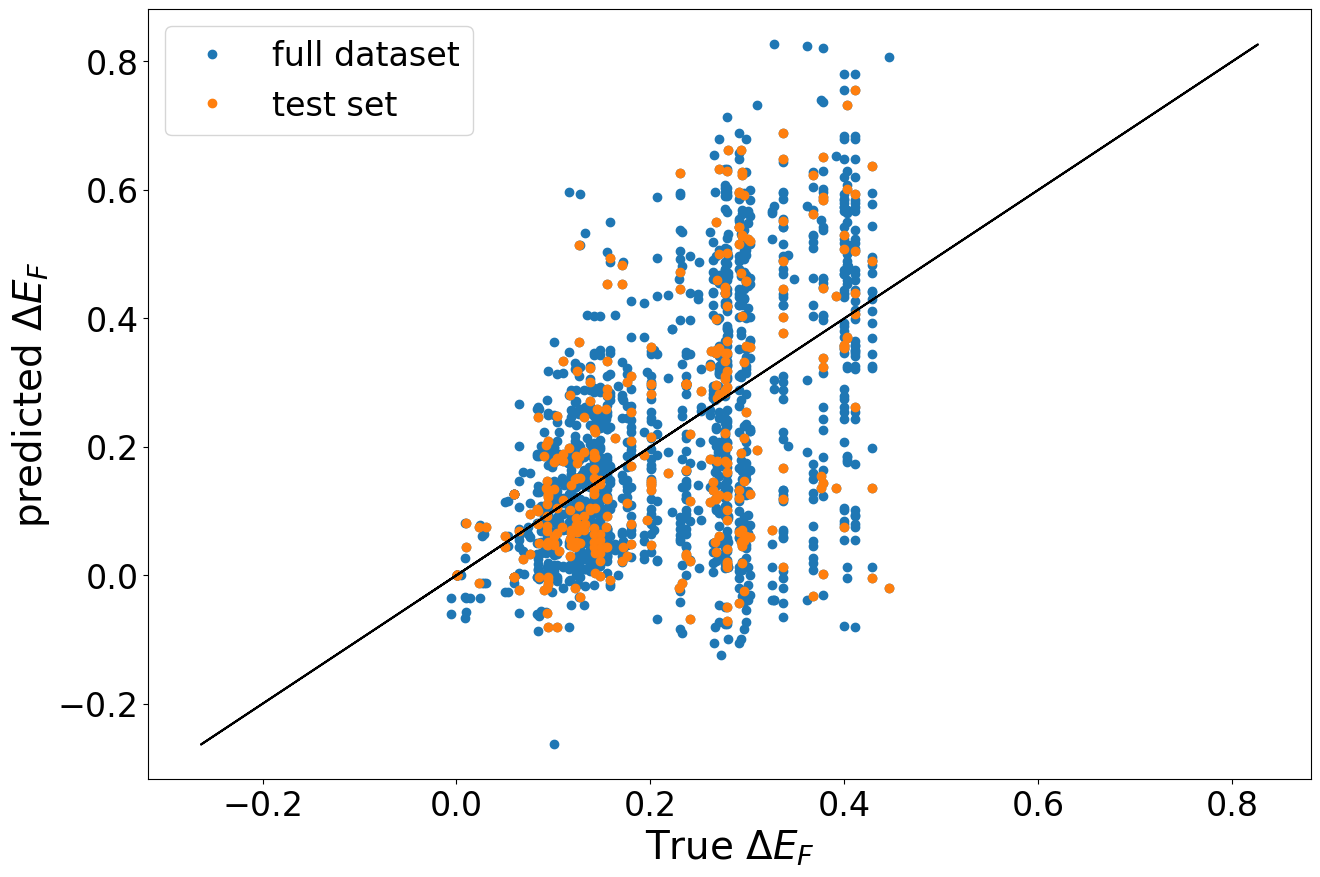

In [60]:
plot_the_prediction_line(YPREDICT,best_Y_test_predict,'BestRandomForest')